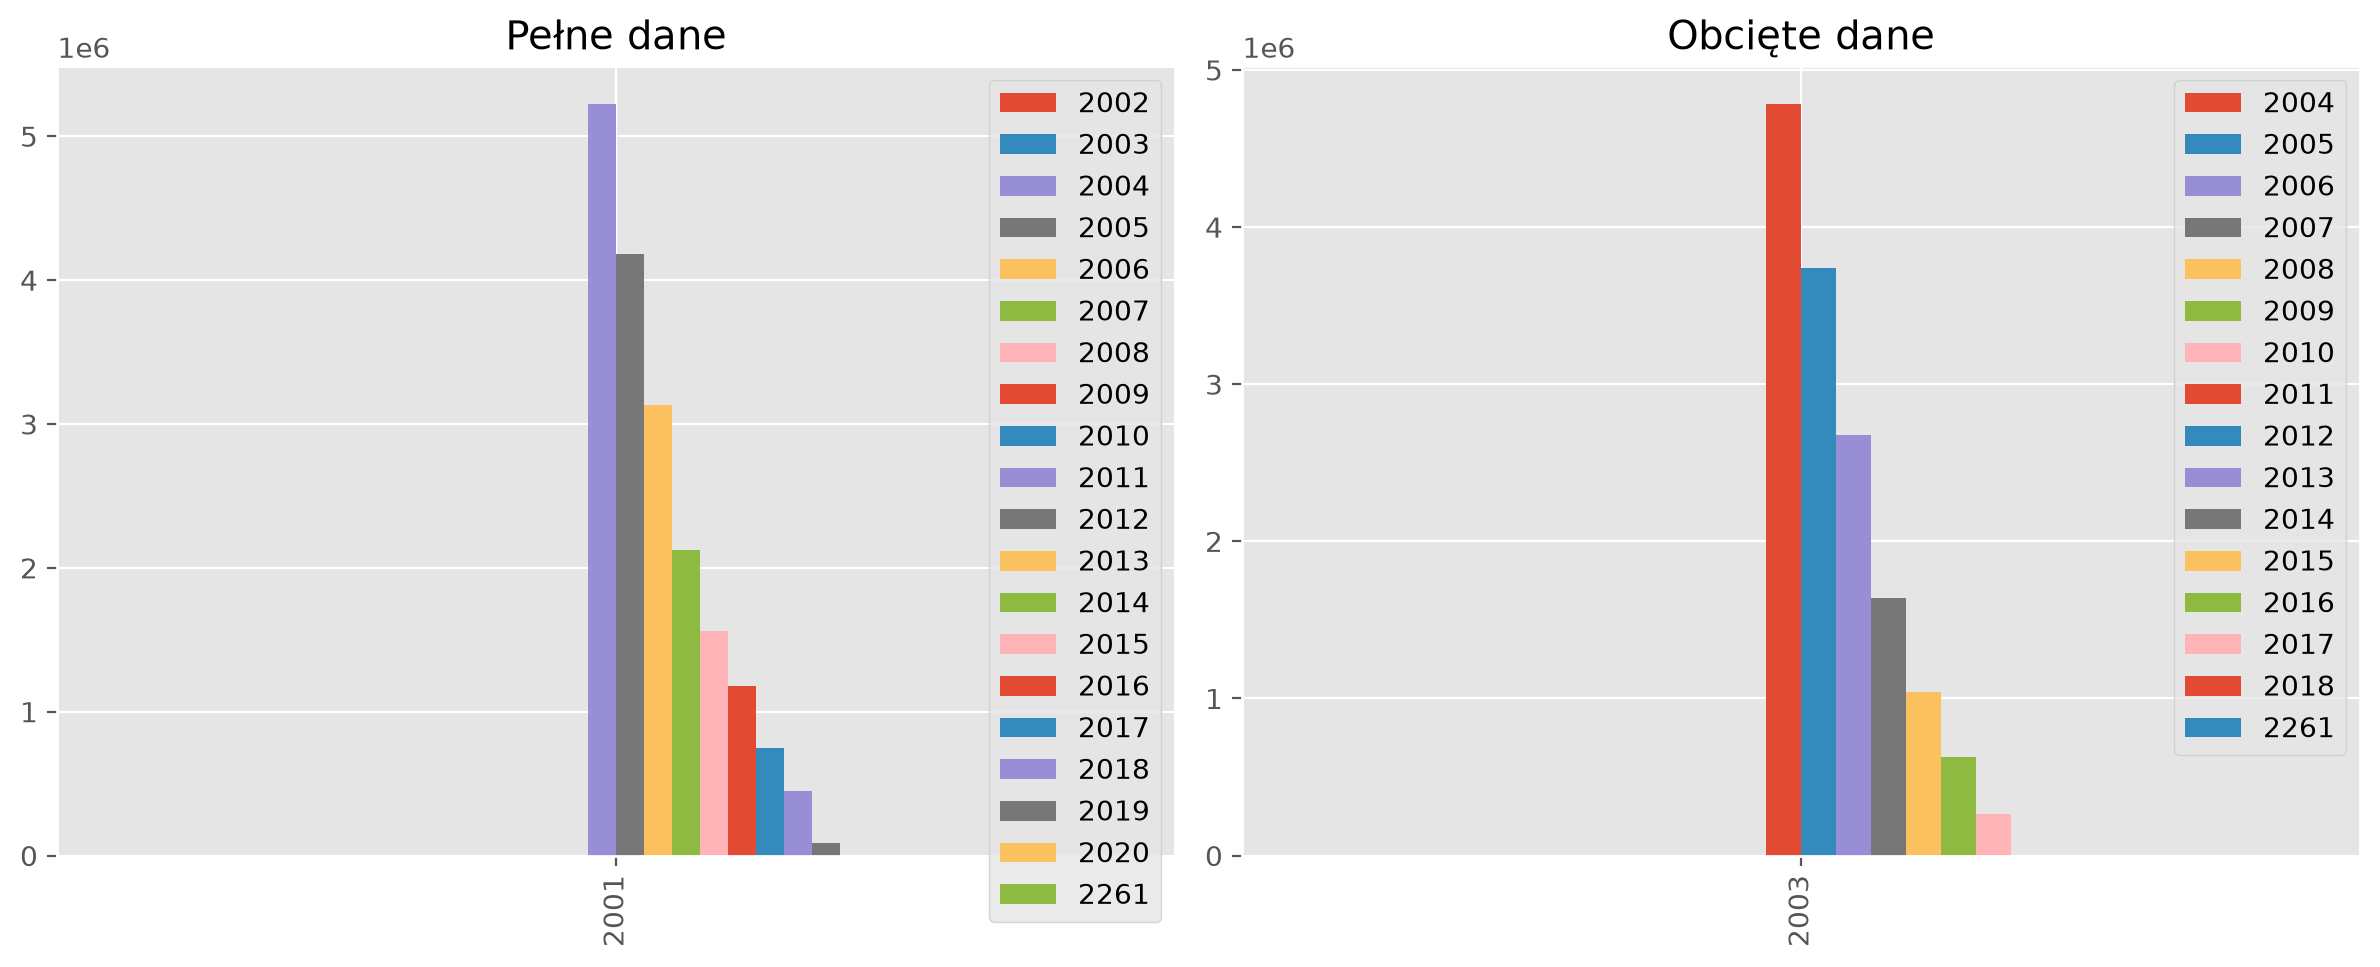

In [ ]:
import chainladder as cl
import matplotlib.pyplot as plt


triangle = cl.load_sample("genins")


model_good = cl.Chainladder().fit(triangle)

runoff_good = (
    model_good.full_triangle_.cum_to_incr()
    - triangle.cum_to_incr()
)

runoff_good = runoff_good[
    runoff_good.valuation > triangle.valuation_date
]

runoff_good = runoff_good.dev_to_val().sum(axis="origin")


triangle_bad = triangle.iloc[:, :, 2:, :-2]

model_bad = cl.Chainladder().fit(triangle_bad)

runoff_bad = (
    model_bad.full_triangle_.cum_to_incr()
    - triangle_bad.cum_to_incr()
)

runoff_bad = runoff_bad[
    runoff_bad.valuation > triangle_bad.valuation_date
]

runoff_bad = runoff_bad.dev_to_val().sum(axis="origin")



fig, ax = plt.subplots(1, 2, figsize=(12, 5))

runoff_good.plot(kind="bar", ax=ax[0])
ax[0].set_title("Pełne dane")

runoff_bad.plot(kind="bar", ax=ax[1])
ax[1].set_title("Obcięte dane")

plt.tight_layout()
plt.show()